# Exploratory Data Analysis

This notebook explores the dataset of exhaled breath measurements. Some general remarks to the dataset:
- Three breathing pattern classes: bradypnea (slow), eupnea (normal), tachypnea (fast)
- Three participants: `a`, `p`, `s`
- Two sensor locations: mouth, nose
- Two sensor channels: humidity in % and temperature in °C

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

Load all breath pattern trials and inspect recording consistency. The dataset contains 645 trials across 3 classes (bradypnea, eupnea, tachypnea) and 3 participants. Trials are uniform: 36 samples over ~70 s at 0.5 Hz. By the Nyquist theorem, the maximum detectable breath rate is 15 breaths per minute, which might be insufficient for all three classes, since even tachypnea typically stays above that threshold.

In [2]:
def load_breath_pattern(classes, dataset_dir='dataset'):
    dataset = []

    # loop through all breath patterns
    for cls in classes:
        folder = os.path.join(dataset_dir, cls)

        # loop through all .dat files
        for fname in sorted(os.listdir(folder)):
            if not fname.endswith('.dat'):
                continue

            # extract metadata
            m = re.match(r'^(([ps])_)?(mouth|nose)_trial_(\d+)\.dat$', fname)
            if m is None:
                continue
        
            # load the data
            df = pd.read_csv(os.path.join(folder, fname))
            dataset.append({'class': cls,
                            'filename': fname,
                            'participant': m.group(2) if m.group(2) else 'a',
                            'region': m.group(3),
                            'trial_num': int(m.group(4)),
                            'time': df['Time'].values / 1000,
                            'humidity': df['Humidity'].values,
                            'temperature': df['Temperature'].values,})

    return pd.DataFrame(dataset)

CLASSES  = ['bradypnea', 'eupnea', 'tachypnea']
dataset = load_breath_pattern(classes=CLASSES)
print(f'Total trials:\t\t\t{len(dataset)},\nClasses:\t\t\t{dataset["class"].unique()},\nParticipants:\t\t\t{dataset["participant"].unique()}')

records = dataset.to_dict('records')
durations = np.array([row['time'][-1] - row['time'][0] for row in records])
n_samples = np.array([len(row['time']) for row in records])
all_intervals = np.concatenate([np.diff(row['time']) for row in records])
print(f"Samples per trial:\t\tmin={n_samples.min()}, max={n_samples.max()}, mean={n_samples.mean():.1f}")
print(f"Trial duration (s):\t\tmin={durations.min():.1f}, max={durations.max():.1f}, mean={durations.mean():.1f}")
print(f"Sampling interval (ms):\t\tmean={all_intervals.mean()*1000:.0f}, std={all_intervals.std()*1000:.0f}")
print(f"Effective sampling rate:\t~{1/all_intervals.mean():.3f} Hz")
print(f"Nyquist limit:\t\t\t{0.5/all_intervals.mean():.2f} Hz -> max detectable breath rate: {0.5/all_intervals.mean()*60:.0f} BPM")

Total trials:			645,
Classes:			['bradypnea' 'eupnea' 'tachypnea'],
Participants:			['a' 'p' 's']
Samples per trial:		min=36, max=36, mean=36.0
Trial duration (s):		min=70.1, max=70.2, mean=70.2
Sampling interval (ms):		mean=2004, std=1
Effective sampling rate:	~0.499 Hz
Nyquist limit:			0.25 Hz -> max detectable breath rate: 15 BPM


First, we need to understand how our raw data look like. The dataset contains 374 nose trials (129/124/121 for B/E/T) and 271 mouth trials (89/86/96), roughly balanced within each source. Classes differ most in their transient rise dynamics: tachypnea rises earliest and steepest, eupnea is intermediate, bradypnea latest, which is consistent with faster breathing delivering moisture sooner. All classes eventually saturate to similar humidity plateaus (~50–60%), so the transient phase (slope, onset, time to plateau) is likely most discriminative. Bradypnea shows the widest inter-trial spread, especially in nose temperature, while eupnea is remarkably consistent. Mouth signals are stronger overall (~5–8 °C vs. ~3–6 °C temperature rise), aligning with the paper who attribute this to greater exhaled volume and report higher classification accuracy for mouth data accordingly. The ~10 s resting baseline is clearly visible, confirming the experimental protocol.

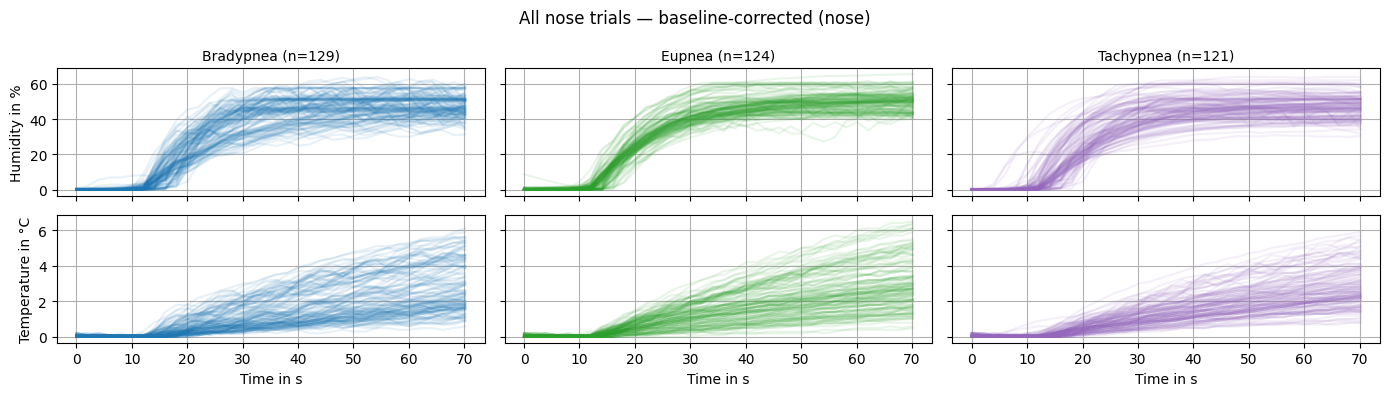

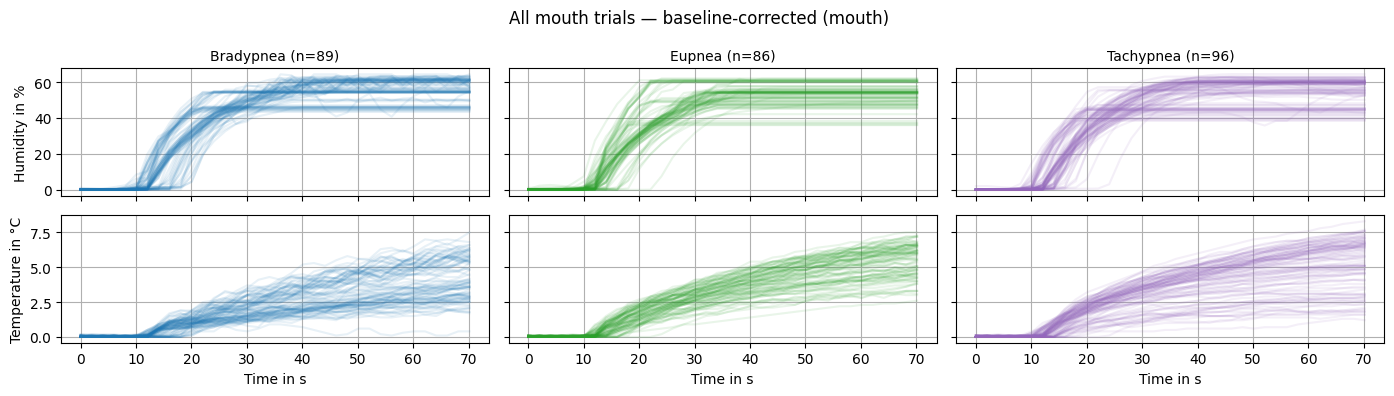

In [3]:
class_colors = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}

for region in ['nose', 'mouth']:
    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex='col', sharey='row')

    for col, cls in enumerate(CLASSES):
        trials = dataset[(dataset['class'] == cls) & (dataset['region'] == region)]

        for row, measurement in enumerate(['humidity', 'temperature']):
            ax = axes[row, col]

            for record in trials.to_dict('records'):
                t = record['time'] - record['time'][0]
                h = record[measurement] - record[measurement].min()
                ax.plot(t, h, color=class_colors[cls], alpha=0.1)

            axes[0, col].set_title(f'{cls.capitalize()} (n={len(trials)})')
            axes[-1, col].set_xlabel('Time in s')
            axes[row, 0].set_ylabel(f'{measurement.capitalize()} in {"%" if measurement == "humidity" else "°C"}')
            ax.grid()

    plt.suptitle(f'All {region} trials — baseline-corrected ({region})')
    plt.tight_layout()
    plt.show()


We see a difference between mouth and nose but lets compare them directly for every pattern. For sake of better clarity, lets only compare the mean and standard deviation. Since the sampling of each trials differ, we first need to resample the trials and map them onto the same time axis. Mouth consistently produces higher and faster-rising signals across all classes, most pronounced in temperature (roughly 1.5–2× the nose response). Humidity plateaus converge more closely between sources (~5–10% gap), while temperature remains clearly separated throughout. Variability (shaded bands) is comparable between sources for eupnea and tachypnea, but noticeably wider for bradypnea, especially nose temperature, reinforcing that bradypnea is the noisiest class. The consistent mouth–nose gap across all three patterns supports treating them as separate datasets rather than pooling.

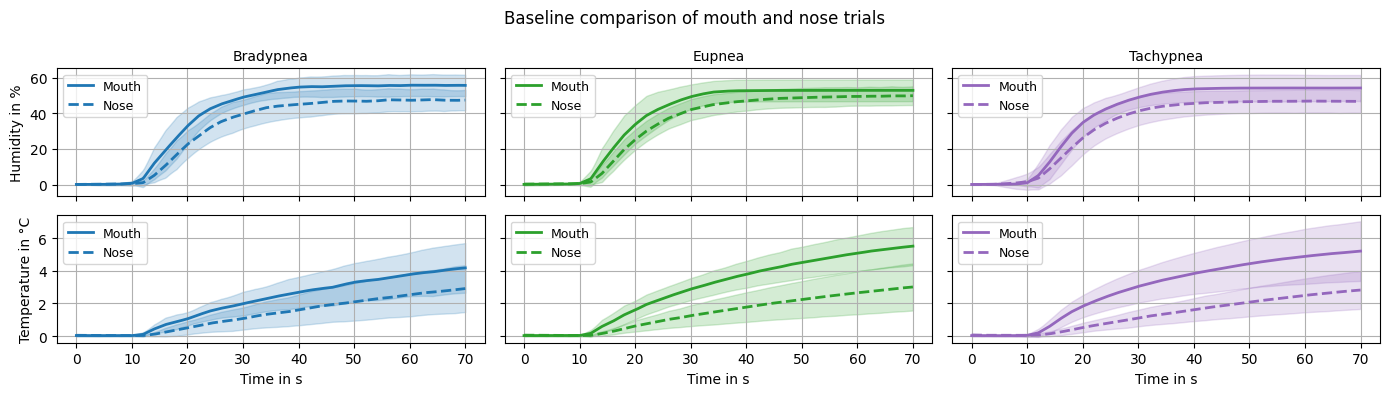

In [4]:
def resample_trials(trials_df, t_common, measurement_type, baseline_correct=True):
    out = []
    for row in trials_df.to_dict('records'):
        t = row['time'] - row['time'][0]
        h = row[measurement_type]
        if baseline_correct:
            h = h - h.min()
        out.append(np.interp(t_common, t, h, left=np.nan, right=np.nan))
    return np.array(out)

t = np.linspace(0, 70, 300)

fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
for col, cls in enumerate(CLASSES):
    for row, measurement in enumerate(['humidity', 'temperature']):
        ax = axes[row, col]
        for region in ['mouth', 'nose']:
            # resample all trials to common time grid
            trials = dataset[(dataset['class'] == cls) & (dataset['region'] == region)]
            trials_resampled = resample_trials(trials, t_common=t, measurement_type=measurement, baseline_correct=True)

            # stats
            mean = np.nanmean(trials_resampled, axis=0)
            std = np.nanstd(trials_resampled,  axis=0)

            # plot
            ax.plot(t, mean, label=region.capitalize(), color=class_colors[cls], linewidth=2.0, linestyle='-' if region == 'mouth' else '--')
            ax.fill_between(t, mean-std, mean+std, alpha=0.2, color=class_colors[cls])
        axes[0, col].set_title(f'{cls.capitalize()}')
        axes[-1, col].set_xlabel('Time in s')
        axes[row, 0].set_ylabel(f'{measurement.capitalize()} in {"%" if measurement == "humidity" else "°C"}')
        ax.grid()
        ax.legend(loc='upper left')

plt.suptitle('Baseline comparison of mouth and nose trials')
plt.tight_layout()
plt.show()

Until now we naively assumed that every trial of each participant is the same. Lets check if this is indeed the case. Participant A consistently produces the strongest signals, meaning higher humidity plateaus and steeper temperature rises, across all three classes, while S tends to be weakest. This likely reflects individual physiological differences (lung capacity, exhalation force, body temperature). The ranking A > P > S is largely preserved across classes, suggesting a systematic participant effect rather than random noise. Notably, the inter-participant gap is most visible in temperature and during the transient phase, while humidity plateaus converge more. Trial counts are reasonably balanced (22–40 per participant-class cell). This participant effect is important: a classifier trained without accounting for it might learn participant identity rather than breath pattern, so leave-one-participant-out evaluation or participant-aware splitting should be considered later.

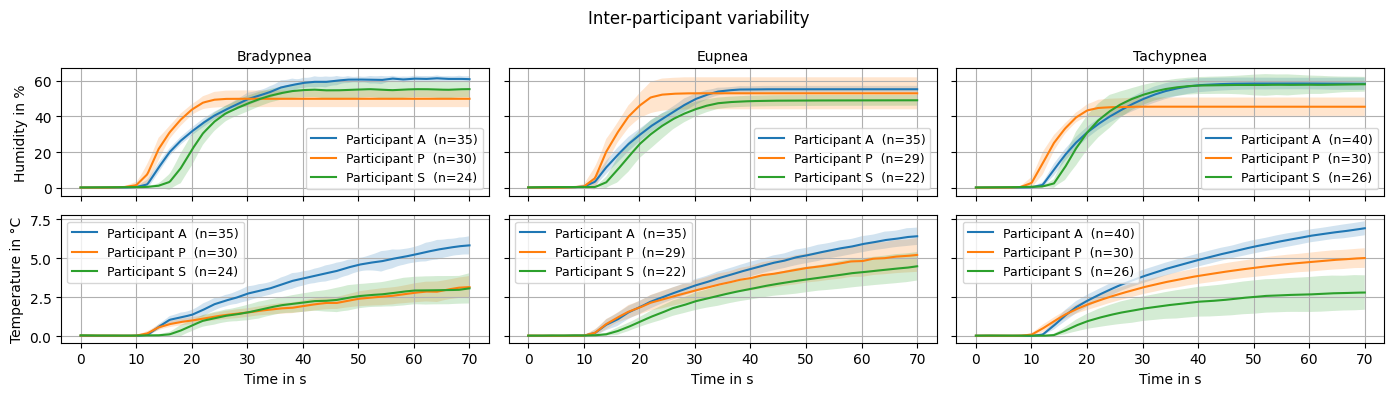

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
for row, measurement in enumerate(['humidity', 'temperature']):
    for col, cls in enumerate(CLASSES):
        ax = axes[row, col]
        for participant in ['a', 'p', 's']:
            # resample all trials to common time grid
            trials = dataset[(dataset['class'] == cls) & (dataset['region'] == 'mouth') & (dataset['participant'] == participant)]
            mat  = resample_trials(trials, t_common=t, measurement_type=measurement, baseline_correct=True)
            
            # stats
            mean = np.nanmean(mat, axis=0)
            std  = np.nanstd(mat,  axis=0)
            
            # plot
            label = f'Participant {participant.upper()}  (n={len(trials)})'
            ax.plot(t, mean, label=label)
            ax.fill_between(t, mean-std, mean+std, alpha=0.2)
        axes[0, col].set_title(f'{cls.capitalize()}')
        axes[-1, col].set_xlabel('Time in s')
        axes[row, 0].set_ylabel(f'{measurement.capitalize()} in {"%" if measurement == "humidity" else "°C"}')
        ax.grid()
        ax.legend(loc='lower right') if row == 0 else ax.legend(loc='upper left')

plt.suptitle('Inter-participant variability')
plt.tight_layout()
plt.show()

Humidity and temperature are physically coupled: exhaled air is warm and saturated with moisture. A high correlation would justify using only one channel, while a lower correlation means both channels provide complementary information. Pearson correlations range from r = 0.60 (Participant S, eupnea) to r = 0.86 (Participant A, bradypnea/tachypnea), indicating a strong but not redundant relationship. Participant A shows the tightest coupling across all classes, while P and S exhibit more scatter, visible as vertical banding at high humidity values, where temperature varies considerably despite humidity being saturated. This confirms that both channels carry partially independent information and should be retained as separate inputs. The nonlinear, curved shape of the scatter (especially for A) also suggests that a linear model would underfit the humidity–temperature relationship, which is relevant for the PINN channel model later.

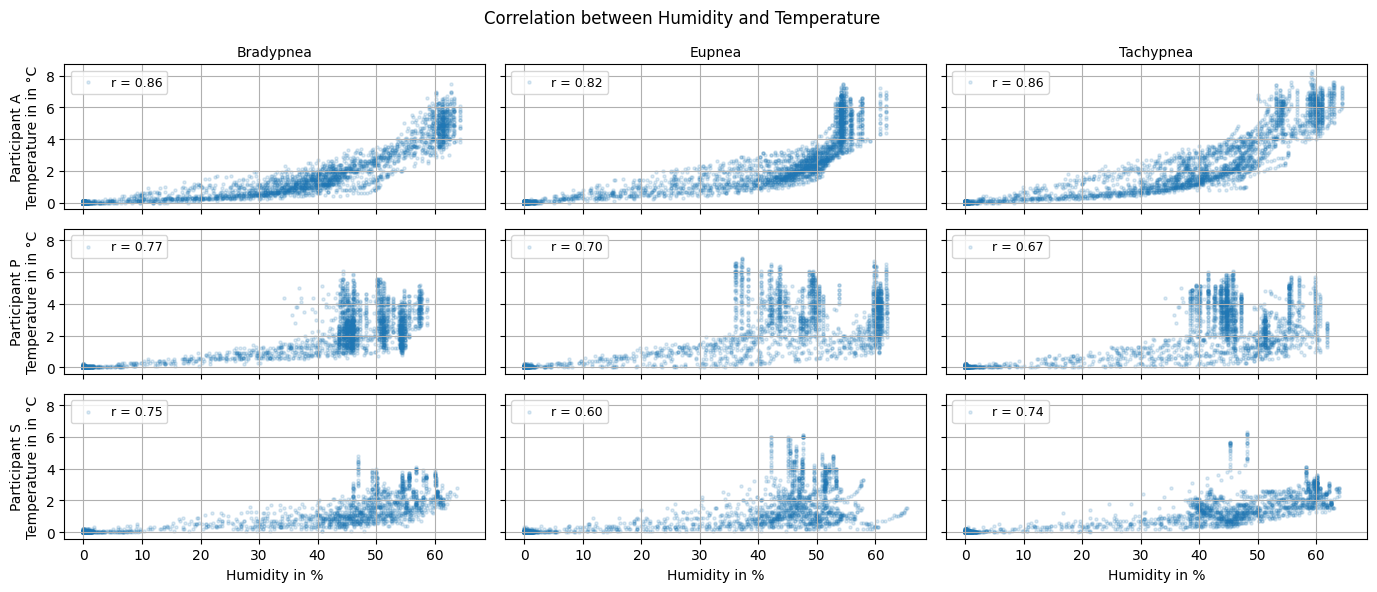

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=True)

for p_idx, participant in enumerate(['a', 'p', 's']):
    for col, cls in enumerate(CLASSES):
        ax = axes[p_idx, col]

        trials = dataset[(dataset['class'] == cls) & (dataset['participant'] == participant)]
        records = trials.to_dict('records')

        all_h = np.concatenate([r['humidity'] - r['humidity'].min() for r in records])
        all_temp = np.concatenate([r['temperature'] - r['temperature'].min() for r in records])
        corr = np.corrcoef(all_h, all_temp)[0, 1]

        ax.scatter(all_h, all_temp, alpha=0.15, s=5, rasterized=True, label=f'r = {corr:.2f}')
        ax.legend(loc='upper left')
        axes[0, col].set_title(f'{cls.capitalize()}')
        axes[-1, col].set_xlabel('Humidity in %')
        axes[p_idx, 0].set_ylabel(f'Participant {participant.upper()}\nTemperature in in °C')
        ax.grid()

plt.suptitle('Correlation between Humidity and Temperature')
plt.tight_layout()
plt.show()
